# Camera Lens Optimization Runner
This notebook provides a structured way to apply evolved black-box optimization algorithms (e.g., from LLaMEA/BLADE) to the **Double-Gauss** camera lens design problem.

In [26]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import time
import importlib.util

# Setup paths to find the simulation and framework
PROJECT_ROOT = os.path.abspath(".")
CAMERA_LENS_ROOT = os.path.join(PROJECT_ROOT, "camera-lens-simulation")
BLADE_FRAMEWORK_ROOT = os.path.join(PROJECT_ROOT, "blade-framework")

if CAMERA_LENS_ROOT not in sys.path:
    sys.path.insert(0, CAMERA_LENS_ROOT)
if BLADE_FRAMEWORK_ROOT not in sys.path:
    sys.path.insert(0, BLADE_FRAMEWORK_ROOT)

from examples.double_gauss_objective import DoubleGaussObjective
print("Environment initialized correctly.")

Environment initialized correctly.


## 1. Objective Initialization & Benchmark
Load the Double-Gauss objective and calculate the initial template loss for benchmarking.

Problem Dimensions: 24
Initial Template Loss: 0.00055854


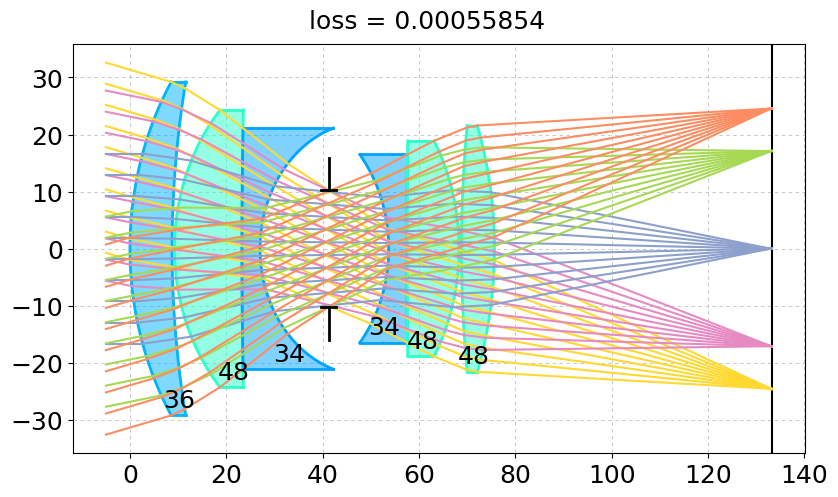

In [27]:
obj = DoubleGaussObjective(enable_grad=True, enable_hessian=False)
lb, ub = obj.bounds()
dim = obj.n_theta

# Initial Benchmark
x0_cont, x0_ids = obj.init_from_templates()
theta0 = obj.pack_theta(x0_cont, x0_ids)
loss0 = obj.objective_theta(theta0)
    grad0_cont = obj.gradient_cont_int(x0_cont, x0_ids)

print(f"Problem Dimensions: {dim}")
print(f"Initial Template Loss: {loss0:.8f}")

# Quick check of the starting point
obj.visualize(theta=theta0, use_latex=False)
plt.show()

## 2. Define or Load Optimizer
Choose **one** of the options below to provide your `Optimizer` class.

In [ ]:
import numpy as np
from scipy.stats import qmc
from scipy.optimize import minimize
import cma



def lhs(n_samples, n_dim=None, **kwargs):
    actual_dim = n_dim if n_dim is not None else kwargs.get('dim', 24); sampler = qmc.LatinHypercube(d=actual_dim)
    sample = sampler.random(n=n_samples)
    return sample * 2 - 1

class Optimizer:
    def __init__(self, budget: int, dim: int, grad0_cont=None):
        self.budget = budget
        self.dim = dim
        self.evals = 0
        self.best_f = float('inf')
        self.best_x = np.zeros(dim)
        self.es = None
        self.trust_region_radius = 0.5
        self.min_trust_region_radius = 0.01

    def _evaluate(self, x, func):
        if self.evals >= self.budget: return float('inf')
        # FORCE ROUNDING OF CATEGORICALS TO NEAREST 0.5 in [-1, 1]
        eval_x = x.copy()
        eval_x[18:24] = np.round(eval_x[18:24] * 2) / 2 
        eval_x[18:24] = np.clip(eval_x[18:24], -1.0, 1.0)
        f = func(eval_x)
        self.evals += 1
        if f < self.best_f:
            self.best_f = f
            self.best_x = eval_x.copy()
        return f

    def _local_search(self, x_cont, x_disc, func, grad_func):
        """Perform local search using L-BFGS-B with trust region constraints"""
        def cost_wrap(x_cont):
            return func(np.concatenate([x_cont, x_disc]))
        
        def grad_wrap(x_cont):
            return grad_func(np.concatenate([x_cont, x_disc]))[:18]
        
        # Define bounds for continuous variables
        bounds = [(-1, 1)] * 18
        
        # Perform local search
        res = minimize(cost_wrap, x_cont, method='L-BFGS-B', jac=grad_wrap, bounds=bounds)
        
        if res.success:
            x_new = np.concatenate([res.x, x_disc])
            return x_new
        return None

    def __call__(self, func, grad_func=None):
        # 1. Initialization (LHS)
        pop = lhs(n_samples=10, n_dim=self.dim)
        for x in pop: self._evaluate(x, func)
        
        # 2. Initialize CMA-ES with best solution
        self.es = cma.CMAEvolutionStrategy(self.best_x.copy(), 0.3)
        
        # 3. Main Loop
        while self.evals < self.budget:
            # CMA-ES generation
            X = self.es.ask()
            F = []
            for x in X:
                f = self._evaluate(x, func)
                F.append(f)
            self.es.tell(X, F)
            
            # Local search with L-BFGS-B on continuous variables if gradient info available
            if grad_func is not None and self.evals < self.budget:
                # Fix discrete variables
                x_disc = self.best_x[18:24]
                x_cont = self.best_x[:18]
                
                # Perform local search
                x_local = self._local_search(x_cont, x_disc, func, grad_func)
                if x_local is not None:
                    self._evaluate(x_local, func)
            
            # Update trust region based on recent improvement
            if self.evals > 10:
                # Reduce trust region if no significant improvement
                if self.evals % 50 == 0:
                    self.trust_region_radius = max(self.min_trust_region_radius, 
                                                   self.trust_region_radius * 0.95)
        
        return self.best_f, self.best_x

In [45]:
# OPTION B: Load Optimizer from a Python file
optimizer_file_path = ""  # e.g., "my_best_optimizer.py"

if optimizer_file_path and os.path.exists(optimizer_file_path):
    spec = importlib.util.spec_from_file_location("custom_opt", optimizer_file_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    Optimizer = module.Optimizer
    print(f"Successfully loaded Optimizer from {optimizer_file_path}")
else:
    print("Using Optimizer defined in the previous cell (Option A).")

Using Optimizer defined in the previous cell (Option A).


## 3. Run Optimization
Execute the selected optimizer against the objective.

In [47]:
budget = 10000
seed = 42
np.random.seed(seed)

print(f"Running {Optimizer.__name__} (Budget={budget}, Seed={seed})...")
import cma
import scipy.optimize
optimizer_instance = Optimizer(budget=budget, dim=dim, grad0_cont=grad0_cont)

def bounded_func(x_normalized):
    x_real = lb + (x_normalized + 1.0) / 2.0 * (ub - lb)
    return obj.objective_theta(np.clip(x_real, lb, ub))

def bounded_grad_func(x_normalized):
    x_real = lb + (x_normalized + 1.0) / 2.0 * (ub - lb)
    grad_real = obj.gradient_theta(np.clip(x_real, lb, ub))
    # Chain rule to convert gradient from real space to normalized space
    grad_normalized = grad_real * (ub - lb) / 2.0
    return grad_normalized

start = time.time()
best_f, best_x_norm = optimizer_instance(bounded_func, bounded_grad_func)
duration = time.time() - start

best_x_real = lb + (best_x_norm + 1.0) / 2.0 * (ub - lb)
best_x_real = np.clip(best_x_real, lb, ub)

print(f"\nOptimization Finished in {duration:.2f}s")
print(f"Initial Loss: {loss0:.6f}")
print(f"Best Loss:    {best_f:.6f}")
print(f"Improvement:  {loss0 - best_f:.6f}")

Running Optimizer (Budget=10000, Seed=42)...


NameError: name 'cma' is not defined

## 4. Visualize Results
Compare the optimized design with the starting point.

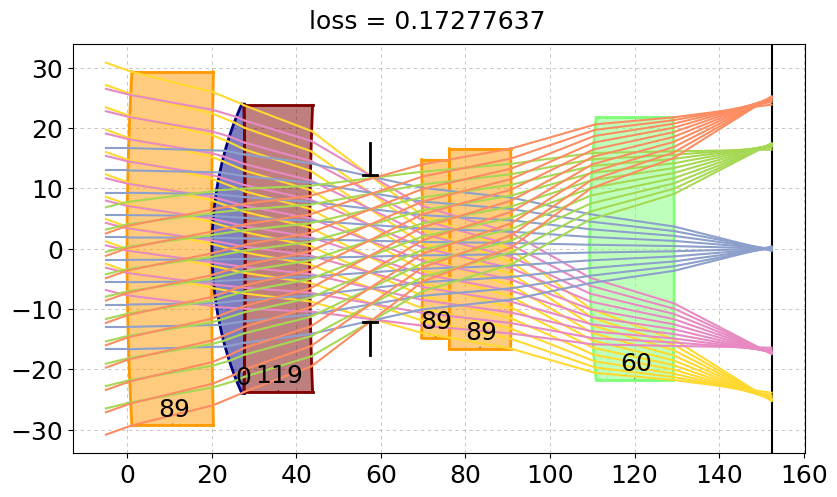

Result saved to lens_visualisation_results/optimized_notebook_1776159147.png


In [39]:
fig, ax, final_loss = obj.visualize(theta=best_x_real, use_latex=False)
plt.show()

# Save the result
os.makedirs("lens_visualisation_results", exist_ok=True)
save_path = f"lens_visualisation_results/optimized_notebook_{int(time.time())}.png"
fig.savefig(save_path)
print(f"Result saved to {save_path}")